In [53]:
# Project: Employee Attrition Analyzer
# Name: Javeria jawaid
# Roll No: 24f-AI-008
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

In [54]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [55]:
df.info()
print(df.describe().T)
print("Missing values:", df.isnull().sum().sum())
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [56]:
df = df.drop(columns=["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"])

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df.shape)

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


C:\Users\HP\AppData\Local\Temp\ipykernel_14832\1441640477.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [57]:
X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train.shape, X_test.shape)

(1176, 44) (294, 44)


In [58]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                             class_weight="balanced", random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                             random_state=42), False),
}

preds, rows = {}, []
for name, (model, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s if use_scaled else X_test
    model.fit(Xtr, y_train)
    p = model.predict(Xte)
    preds[name] = p
    rows.append({"Model": name,
                 "Train Acc": model.score(Xtr, y_train),
                 "Test Acc": accuracy_score(y_test, p),
                 "Precision": precision_score(y_test, p),
                 "Recall": recall_score(y_test, p),
                 "F1": f1_score(y_test, p)})

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Train Acc,Test Acc,Precision,Recall,F1
Model,,,,,
Logistic Regression,0.779,0.752,0.345,0.617,0.443
Decision Tree,0.846,0.769,0.356,0.553,0.433
Random Forest,1.000,0.823,0.419,0.277,0.333


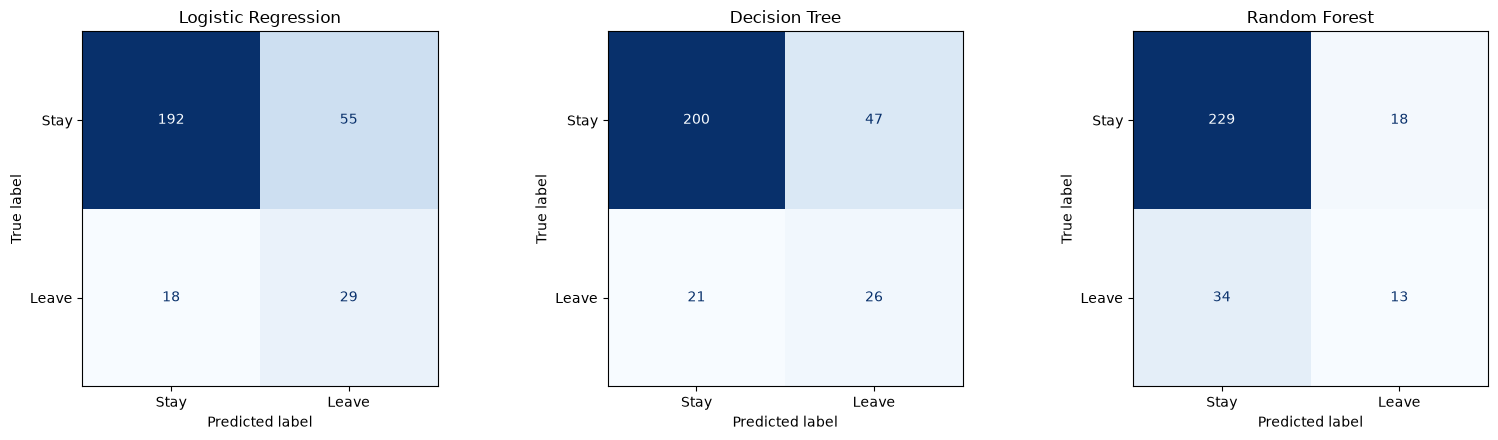

Logistic Regression
              precision    recall  f1-score   support

        Stay       0.91      0.78      0.84       247
       Leave       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

Decision Tree
              precision    recall  f1-score   support

        Stay       0.90      0.81      0.85       247
       Leave       0.36      0.55      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.82      0.77      0.79       294

Random Forest
              precision    recall  f1-score   support

        Stay       0.87      0.93      0.90       247
       Leave       0.42      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.65      0.60      0.62       294
weighted avg       0.80   

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, p) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p),
                           display_labels=["Stay", "Leave"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

for name, p in preds.items():
    print("=" * 50); print(name)
    print(classification_report(y_test, p, target_names=["Stay", "Leave"]))

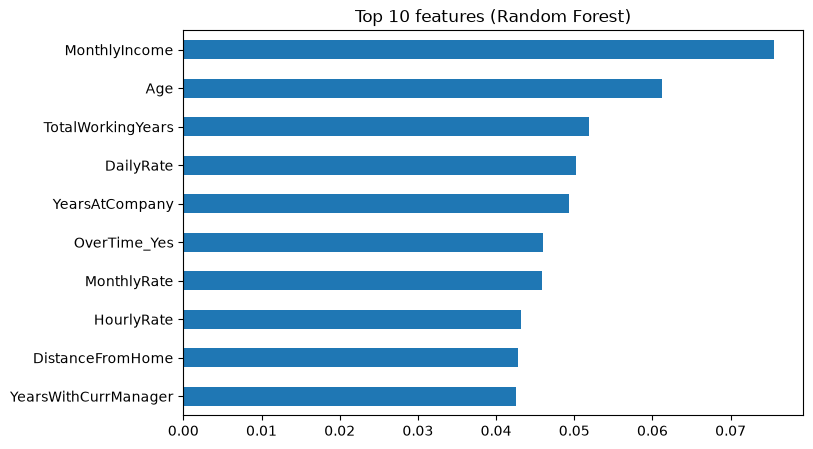

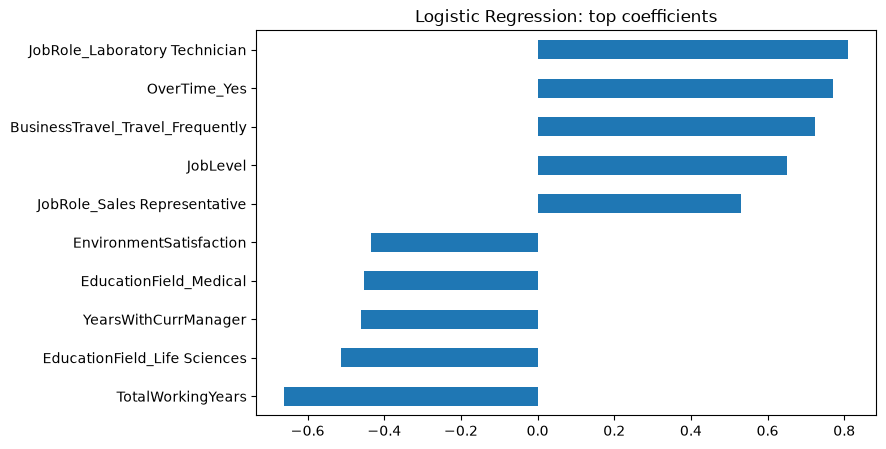

In [60]:
rf = models["Random Forest"][0]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot(kind="barh", figsize=(8, 5), title="Top 10 features (Random Forest)")
plt.show()

lr = models["Logistic Regression"][0]
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
pd.concat([coef.head(5), coef.tail(5)]).plot(kind="barh", figsize=(8, 5),
    title="Logistic Regression: top coefficients")
plt.show()

## PROJECT : Employee Attrition Analyzer
## NAME : JAVERIA JAWAID
## ROLL NO : 24F-AI-008

## Conclusion

**Best model: Logistic Regression.**
It achieved the highest F1 score (0.443) and the highest recall (0.617) of the three models. This means it identified the largest share of employees who actually left, which is the main goal of an attrition analyzer. Its train accuracy (0.779) and test accuracy (0.752) are very close, so it shows no signs of overfitting.

**Decision Tree:** F1 = 0.433 and recall = 0.553, very close to Logistic Regression. The gap between train (0.846) and test (0.769) accuracy is slightly larger, but limiting the depth (max_depth=5) kept overfitting under control.

**Random Forest:** It has the highest test accuracy (0.823), but this is misleading. Its recall is only 0.277, so it failed to detect most employees who left. Its train accuracy of 1.000 versus 0.823 on the test set also shows clear overfitting.

**Accuracy vs. F1/Recall:** The dataset is imbalanced (only about 16% of employees left the company). Judging by accuracy alone would make Random Forest look best, while it is actually the weakest at finding employees at risk. For this reason, F1 score and recall were given more weight than accuracy.

**Important features:**
- **Random Forest:** The most important features are MonthlyIncome, Age, TotalWorkingYears, DailyRate, and YearsAtCompany. The importance values are fairly spread out (about 0.04 to 0.075), so no single feature dominates the prediction.
- **Logistic Regression:** The features that increase the chance of leaving are OverTime (Yes), frequent business travel (BusinessTravel_Travel_Frequently), and the Laboratory Technician and Sales Representative job roles. The features that reduce it are higher EnvironmentSatisfaction, more YearsWithCurrManager, and more TotalWorkingYears.
- **Common findings:** Both models rank OverTime, TotalWorkingYears, and YearsWithCurrManager among their top features. Overtime pushes employees towards leaving, while experience and a long relationship with the same manager make them more likely to stay.
- **Note:** JobLevel has a positive coefficient, which is unexpected. This is probably because it is strongly correlated with MonthlyIncome and TotalWorkingYears, so the coefficient should not be read on its own.

**Limitations and improvements:** Precision is low for all three models (0.35-0.42), meaning many employees were wrongly flagged as likely to leave. Possible improvements include hyperparameter tuning (GridSearchCV), handling the imbalance with SMOTE, adjusting the decision threshold, and adding more features.